# Hypothesis Test — Does Sentiment Differ Between iOS and Android?

**Question:** Do Beli users on the App Store (iOS) and Google Play (Android) express
different overall sentiment?

**Method:** A permutation test on star ratings.
- **H0 (null):** the two platforms have the same mean rating — any observed gap is chance.
- **H1 (alternative):** the two platforms have different mean ratings.

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42) 

In [93]:
df = pd.read_csv("data/tagged_reviews.csv")
df = df[["source", "rating"]].dropna()
df.head()

,source,rating
0,app_store,1
1,app_store,1
2,app_store,5
3,app_store,2
4,app_store,1


### The test statistic

I compare the **difference in mean rating** between the two platforms. This helper
computes that difference for any grouping label — I'll reuse it for both the real
data and the shuffled data, so the calculation is identical every time.

In [94]:
def difference_of_means(data, value_col, group_col):
    """Difference in mean of `value_col` between the two groups in `group_col`.
    Returns: group[1] mean - group[0] mean (alphabetical order)."""
    means = data.groupby(group_col)[value_col].mean()
    return means.iloc[1] - means.iloc[0]

In [95]:
observed_diff = difference_of_means(df, "rating", "source")
print(f"Observed difference in mean rating: {observed_diff:.3f}")

Observed difference in mean rating: -0.306


### One shuffle

If platform truly doesn't matter (H0), the labels are arbitrary — I can shuffle them
and the difference should be near zero on average. This function shuffles the platform
labels once and recomputes the difference. Running it many times builds the
**null distribution**: what the difference looks like when platform is random.

In [96]:
def one_simulated_difference(data, value_col, group_col):
    """Shuffle the group labels once, then recompute the difference of means."""
    shuffled = data[[value_col]].copy()
    shuffled["shuffled_label"] = rng.permutation(data[group_col].values)
    return difference_of_means(shuffled, value_col, "shuffled_label")

### Build the null distribution

Repeat the shuffle 10,000 times, collecting the difference each time. This is the
distribution of differences we'd expect if the two platforms were truly the same.

In [97]:
n_iter = 10000
simulated_diffs = np.array([
    one_simulated_difference(df, "rating", "source")
    for _ in range(n_iter)
])

### Compare observed vs. null

The histogram is the null distribution; the red line is the difference we actually
observed. If the red line sits in the bulk, the platforms don't meaningfully differ.
If it sits far in a tail, the difference is unlikely to be chance.

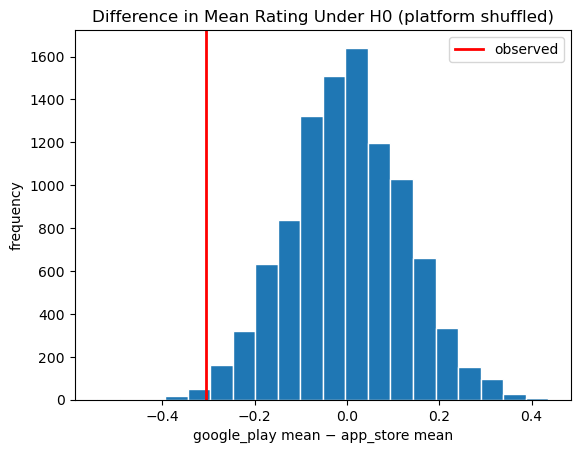

In [98]:
plt.hist(simulated_diffs, bins=20, edgecolor="white")
plt.axvline(observed_diff, color="red", lw=2, label="observed")
plt.title("Difference in Mean Rating Under H0 (platform shuffled)")
plt.xlabel("google_play mean − app_store mean")
plt.ylabel("frequency")
plt.legend()
plt.show()

### P-value

The two-sided p-value is the fraction of shuffled differences at least as extreme
(in either direction) as the observed one. Small p (< 0.05) means a gap this large
is unlikely under H0, so we reject it.

In [99]:
p_value = np.mean(np.abs(simulated_diffs) >= np.abs(observed_diff))
print(f"Observed difference: {observed_diff:.3f}")
print(f"Two-sided p-value:   {p_value:.4f}")

Observed difference: -0.306
Two-sided p-value:   0.0153


## Conclusion

Two-sided permutation test: **p = 0.0153**. Since the p-value is below 0.05, so **we reject the null** — iOS and Android
users show different sentiment toward Beli.

The observed difference was **−0.306** (google_play − app_store): **iOS users rated
Beli ~0.31 stars higher** than Android users. Consistent with Beli's iOS-first,
Gen-Z audience.

**Limitations:** sentiment proxied by star rating (ordinal treated as numeric); reviewers
self-select toward extremes, so this reflects vocal users, not the median user.